# 04c — Alberta foothills results: candidate areas

Results for the ab_foothills run (`config.ANALYSES["ab_foothills"]`). **NEW candidate areas** = the small high-value areas surfaced with compactness off; **benchmark** = the existing PAs inside the foothills window. **Requires** `output_data/iter6_ab_foothills/` (run 03c first). **Kernel:** `.venv` (Python).

In [1]:
# ---- Setup: shared results engine + this analysis' key -------------------
import importlib
import results_core as rc, config
importlib.reload(config); importlib.reload(rc)

ANALYSIS = "ab_foothills"   # <-- the ONLY line that differs between 04a / 04b / 04c
A = rc.load(ANALYSIS)          # locate the run + region label + map outline + benchmark spec
rc.load_rasters(A)             # portfolio + selection-frequency rasters

analysis=ab_foothills | run=iter6_ab_foothills | objective=min_shortfall | proportion/LP
region=Alberta foothills | figures -> output_data/iter6_ab_foothills/figures
portfolio: 1 solution(s) | grid 551 x 891
allocation surface: 0.00..1.00


<results ab_foothills | iter6_ab_foothills | 551x891>

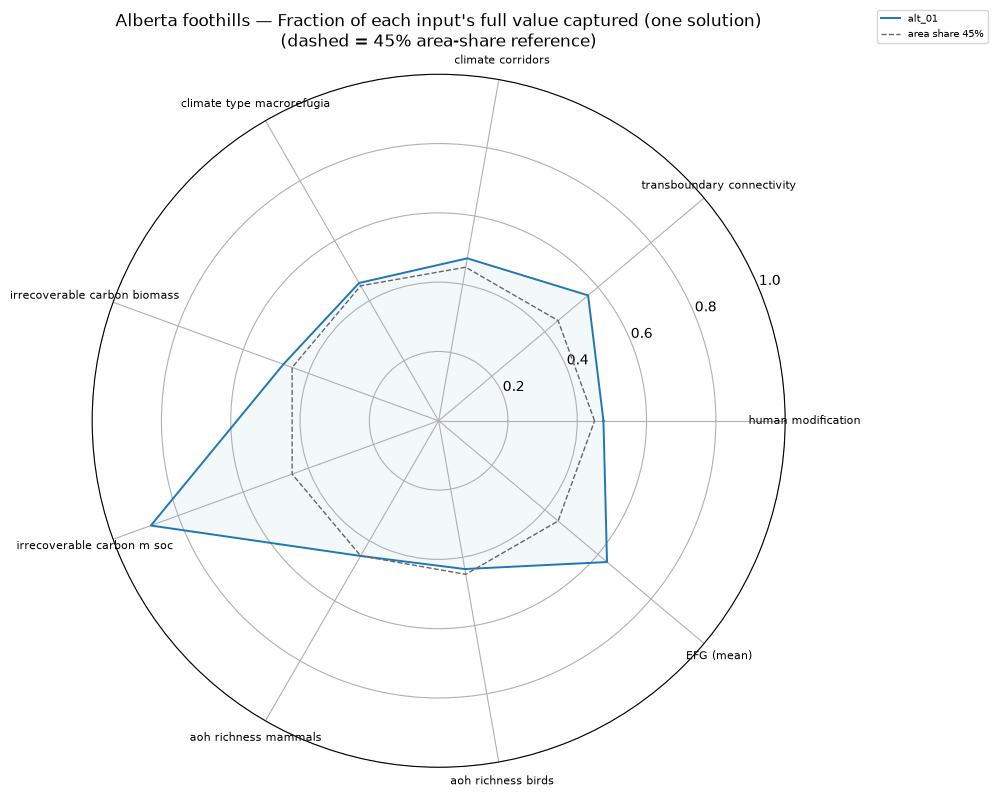

In [2]:
# ---- Radar: captured fraction per input vs the area-share ring ----
rc.radar(A)

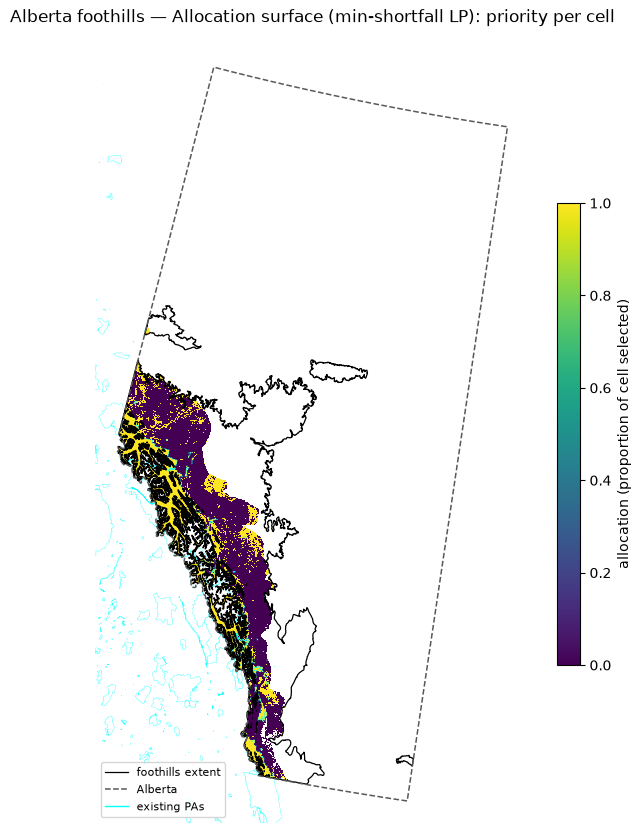

In [3]:
# ---- Allocation surface / selection-frequency map ----
rc.allocation_map(A)

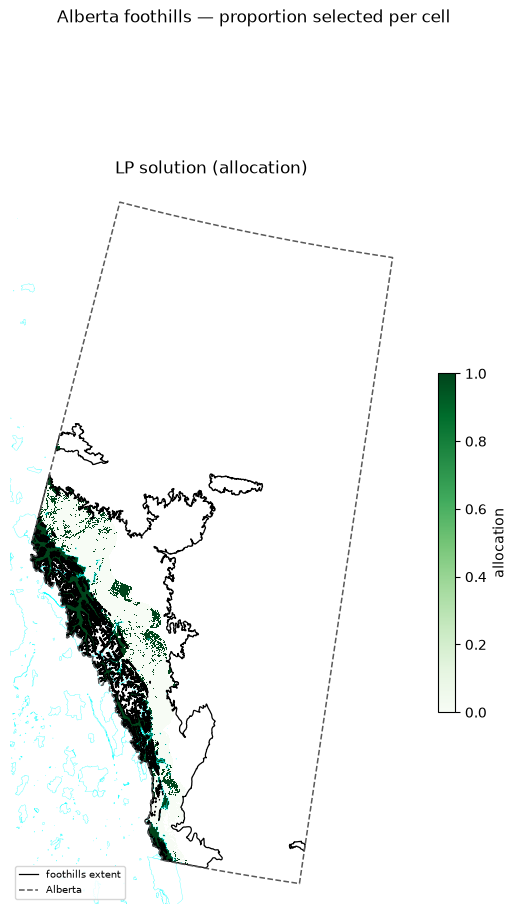

In [4]:
# ---- Solution map(s) ----
rc.solution_maps(A)

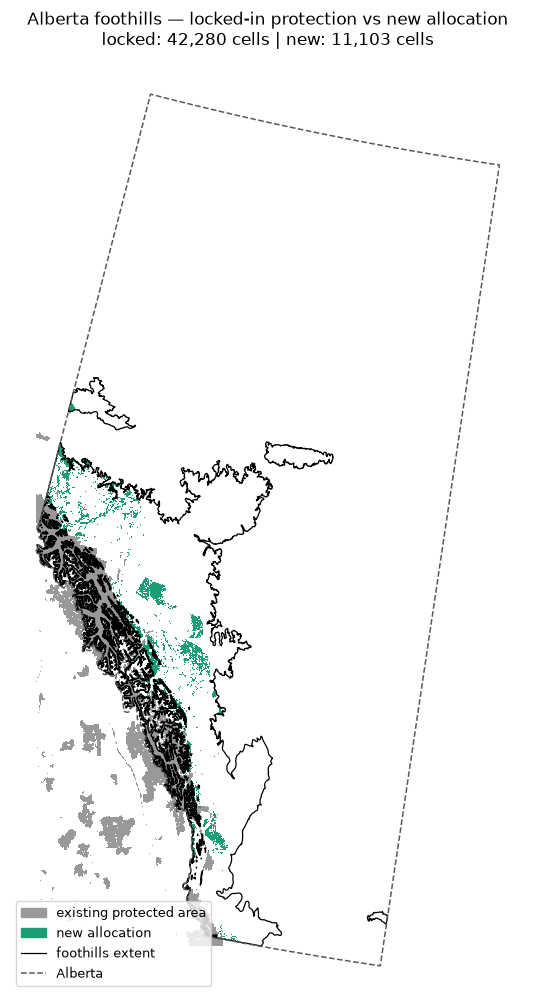

In [5]:
# ---- Existing protection vs new allocation ----
rc.existing_vs_new(A)

In [6]:
# ---- Trade-off table + headline stats ----
rc.tradeoff(A)

Per-solution summary:
alternative  n_selected  pct_region  n_added_beyond_pa
     alt_01    34225.65          45              11102

window planning units : 76,057
area budget (cells)   : 34,226 (45%)
locked-in             : 23,123 (30.4% of window)
area selected         : 45.0% of window


## Candidate areas vs the existing-protection benchmark

`build_stacks` loads the feature stacks, computes **full-Y2Y** region totals (so contribution / efficiency stay “% of Y2Y”), and profiles: the **NEW candidate areas** (connected blocks of new allocation) and the analysis' **benchmark** block (y2y: featured parks + Ross River; north_bc: the 4 IPCA anchors; ab_foothills: the existing in-window PAs). Each area gets three star-plot views + the consequences tables. Figures/CSVs → the run's folder.

**Naming & layout:** the new candidate areas are numbered **Option 1–N** in the order they are selected (the same numbers annotate `rc.new_map`); benchmark / manual areas keep their real names. The consequences tables split their columns into two groups — *Alternatives (new options)* vs *Established Protected/Priority Areas* — and every value prints to at least **2 significant figures** (small cells gain decimals rather than rounding to `0.0`).

In [7]:
# ---- Build stacks + profile NEW clusters + benchmark block (+ manual area) ----
rc.build_stacks(A)

new candidate areas   : 609 components, 6 kept (>= 25 cells, largest)
benchmark areas       : 6 profiled [named_pa]
cell size 1.0 km^2 | full-Y2Y PU denom = 1,272,914
shared efficiency scale EFF_RMAX = 0.40 %/1,000 km^2


<results ab_foothills | iter6_ab_foothills | 551x891 | 6 new clusters>

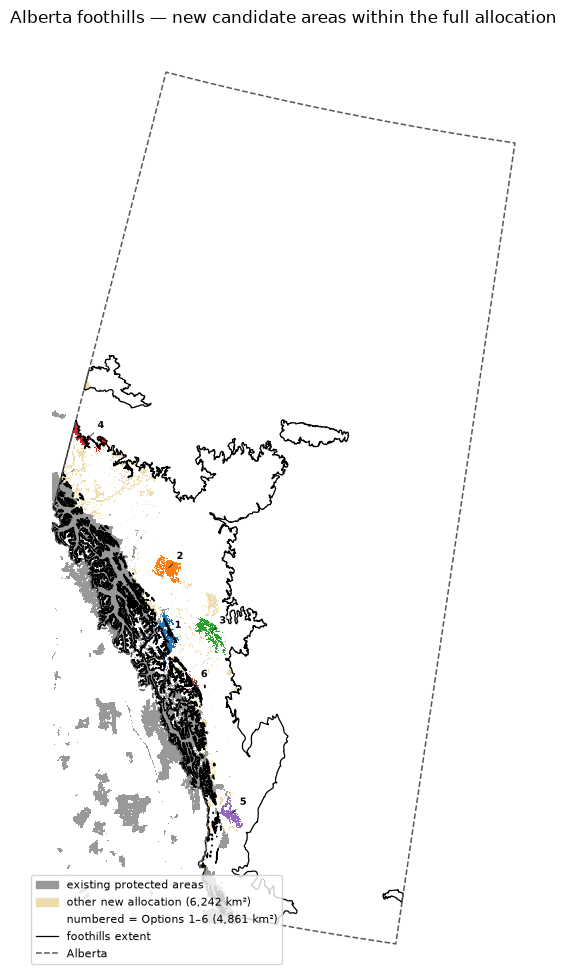

In [8]:
# ---- New candidate areas: map (colored, numbered) within the full allocation ----
rc.new_map(A)

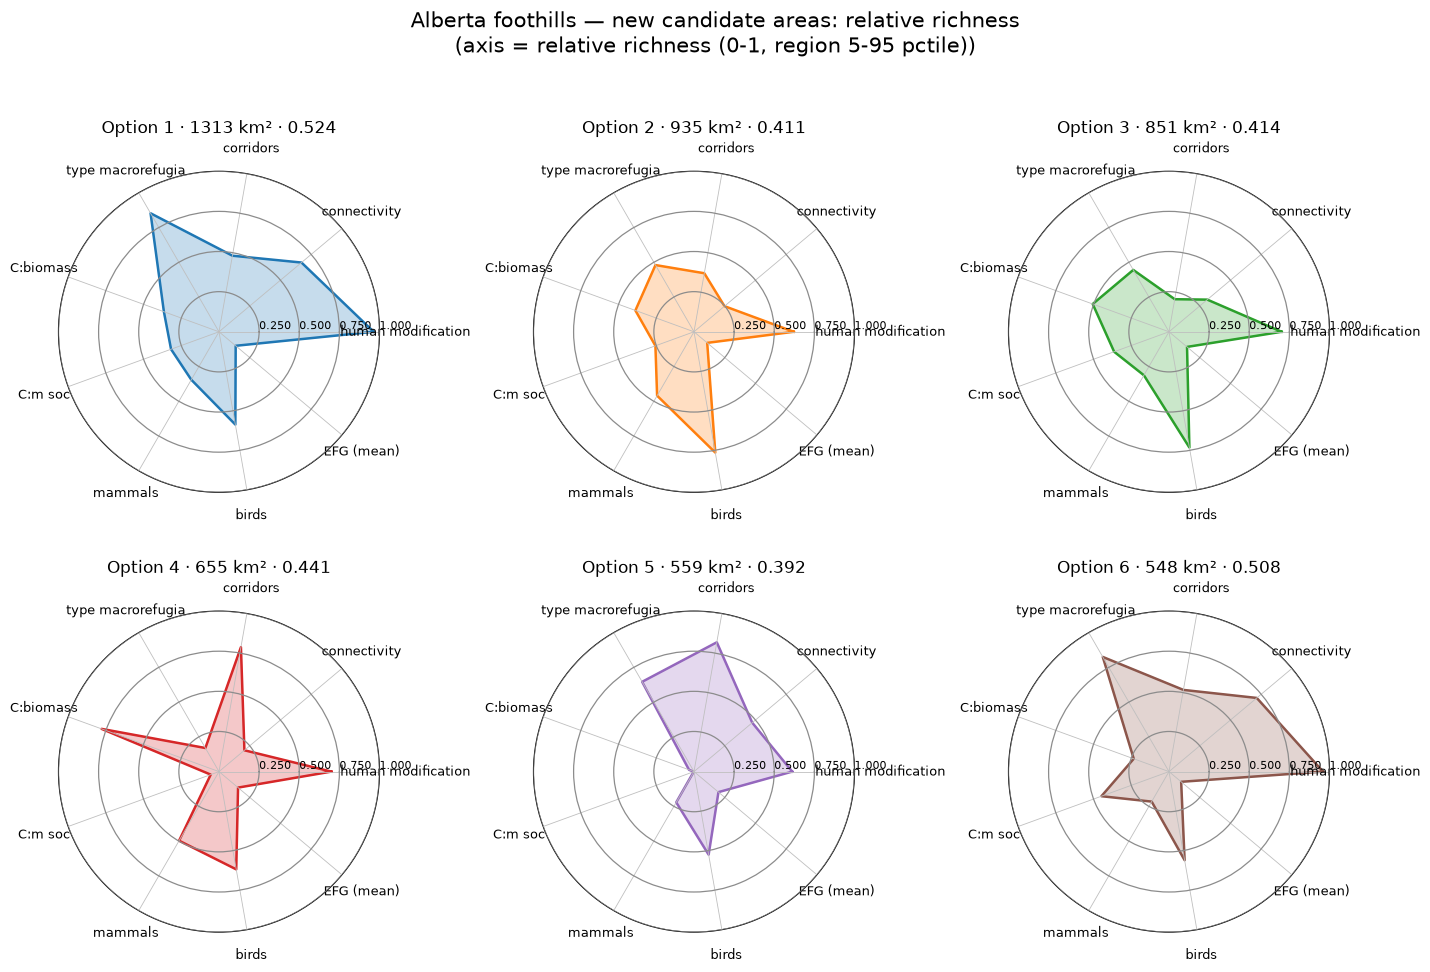

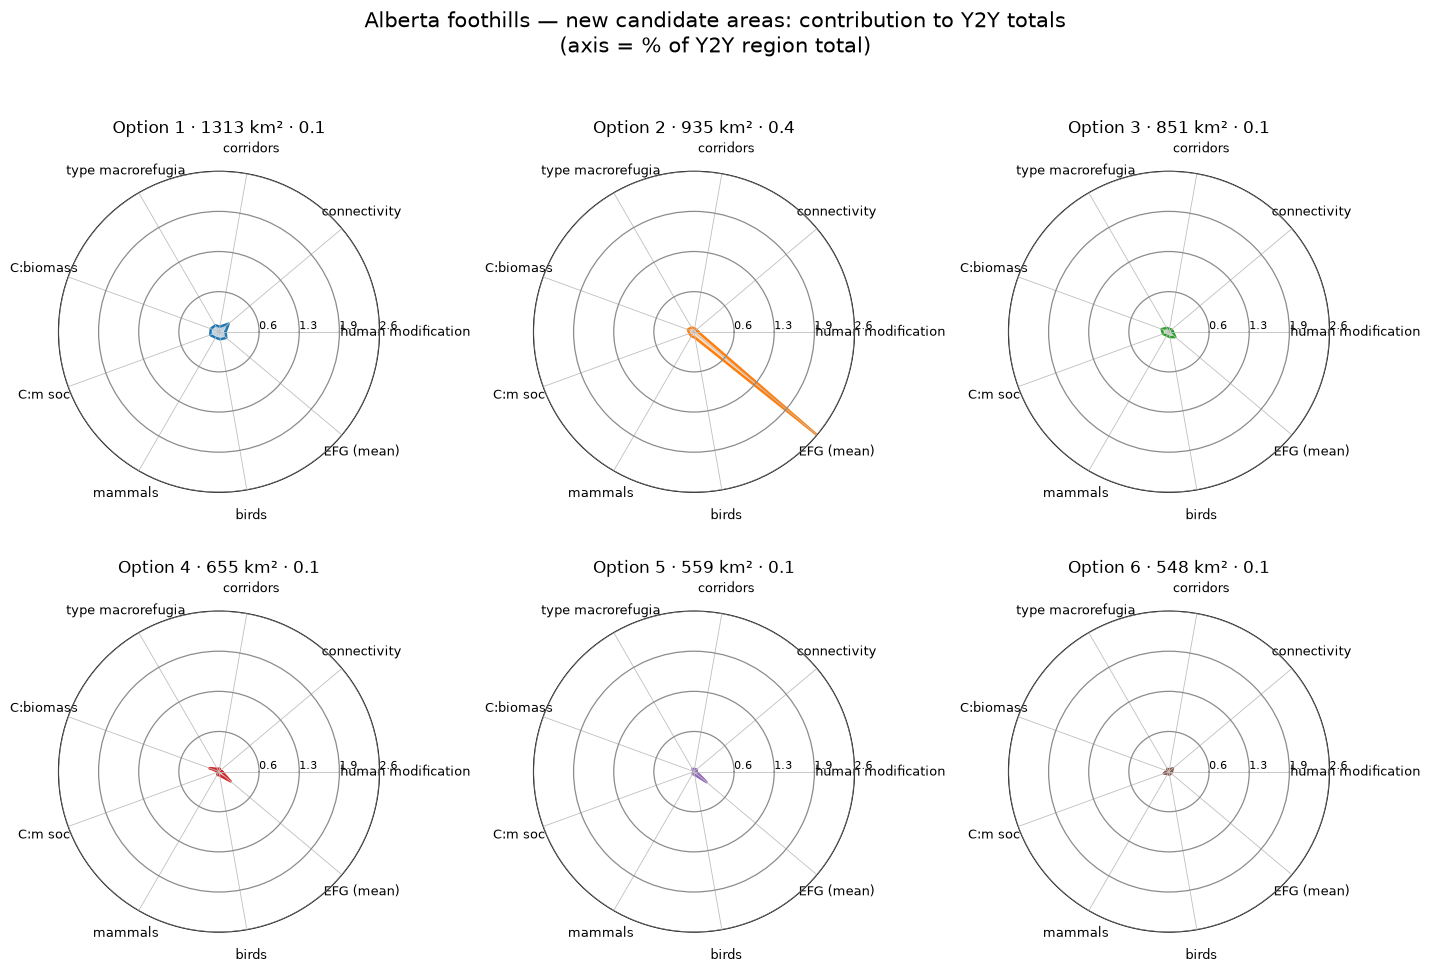

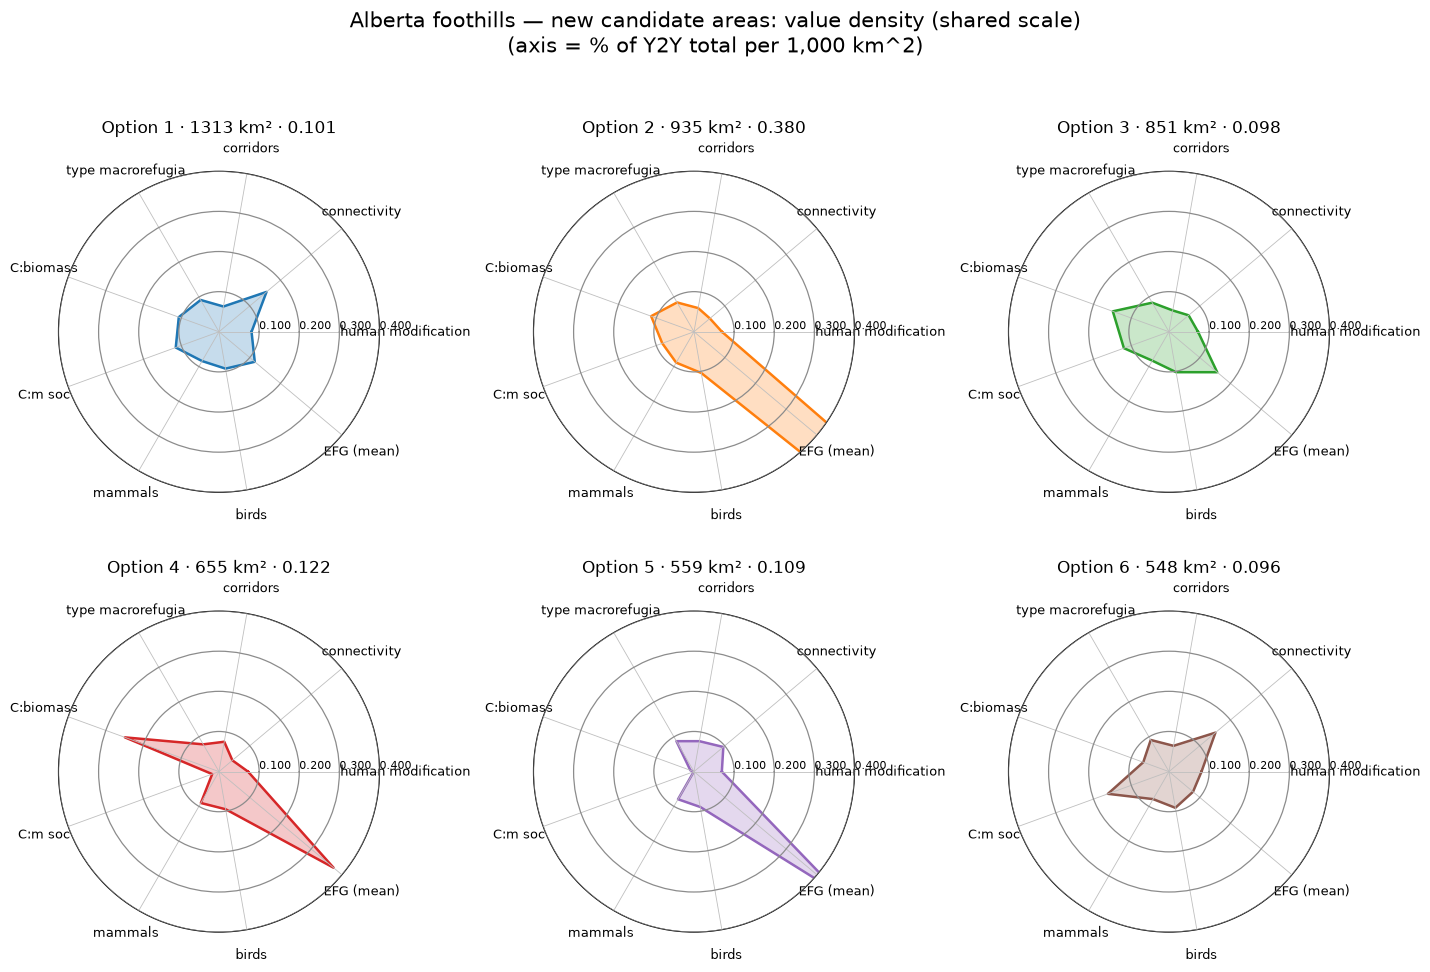

In [9]:
# ---- New candidate areas: 3 star-plot views (richness / contribution / efficiency) ----
rc.new_stars(A)

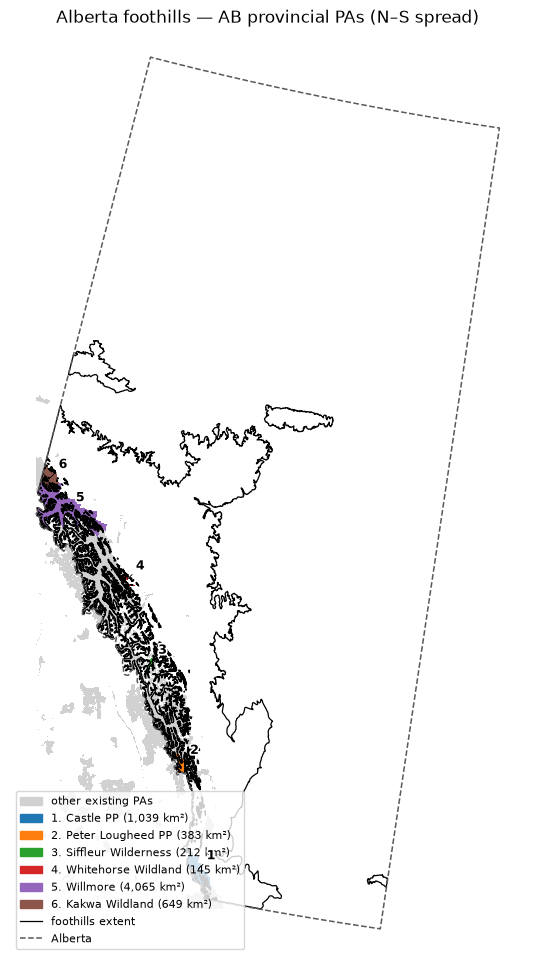

In [10]:
# ---- Benchmark areas: map ----
rc.bench_map(A)

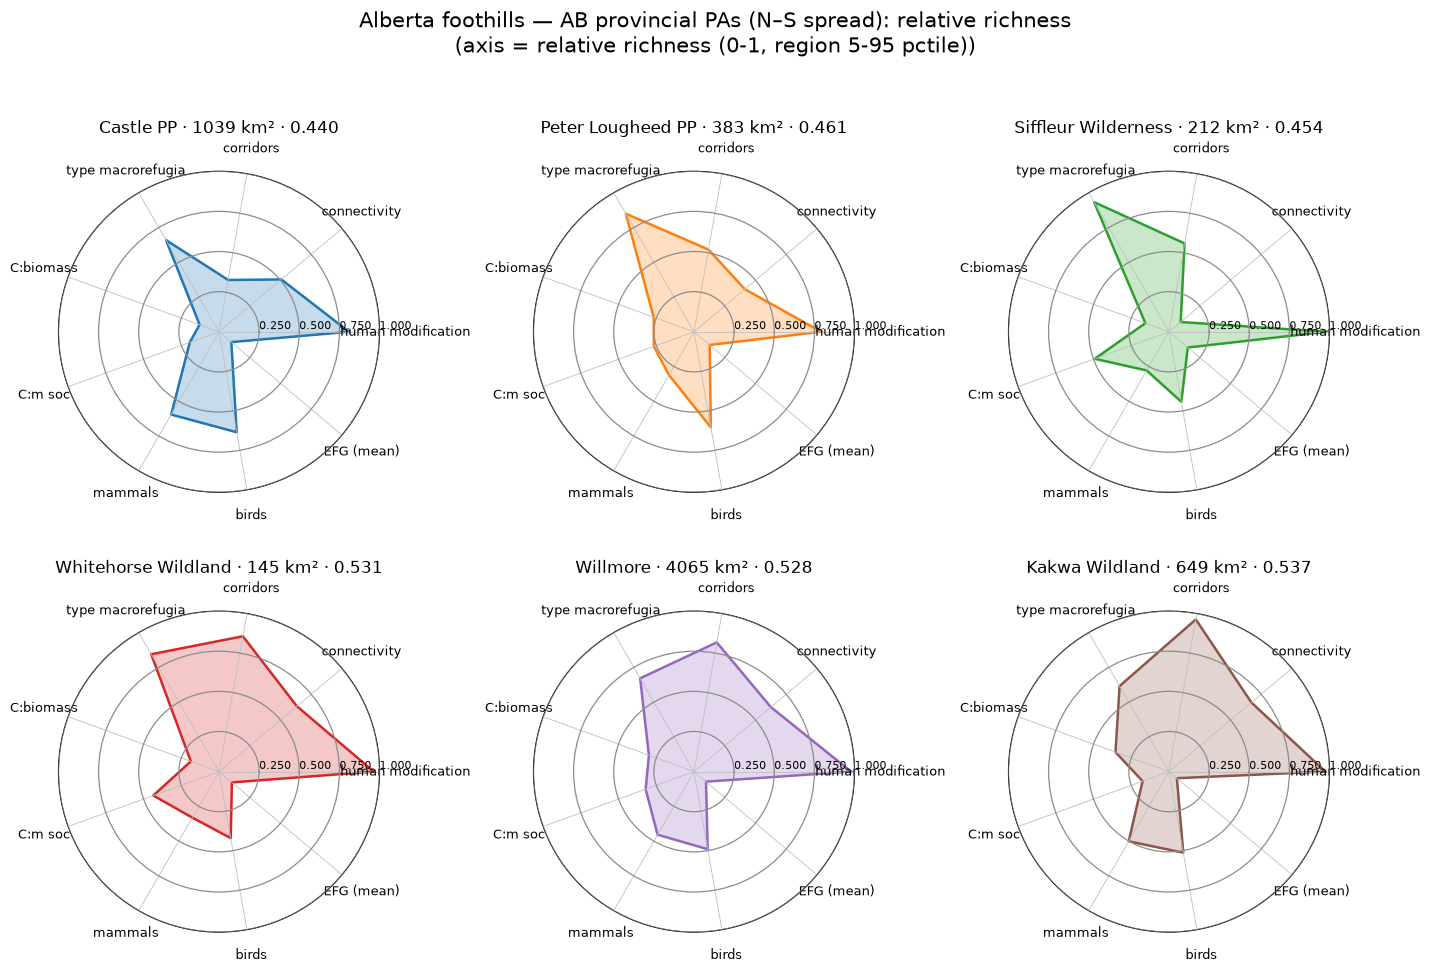

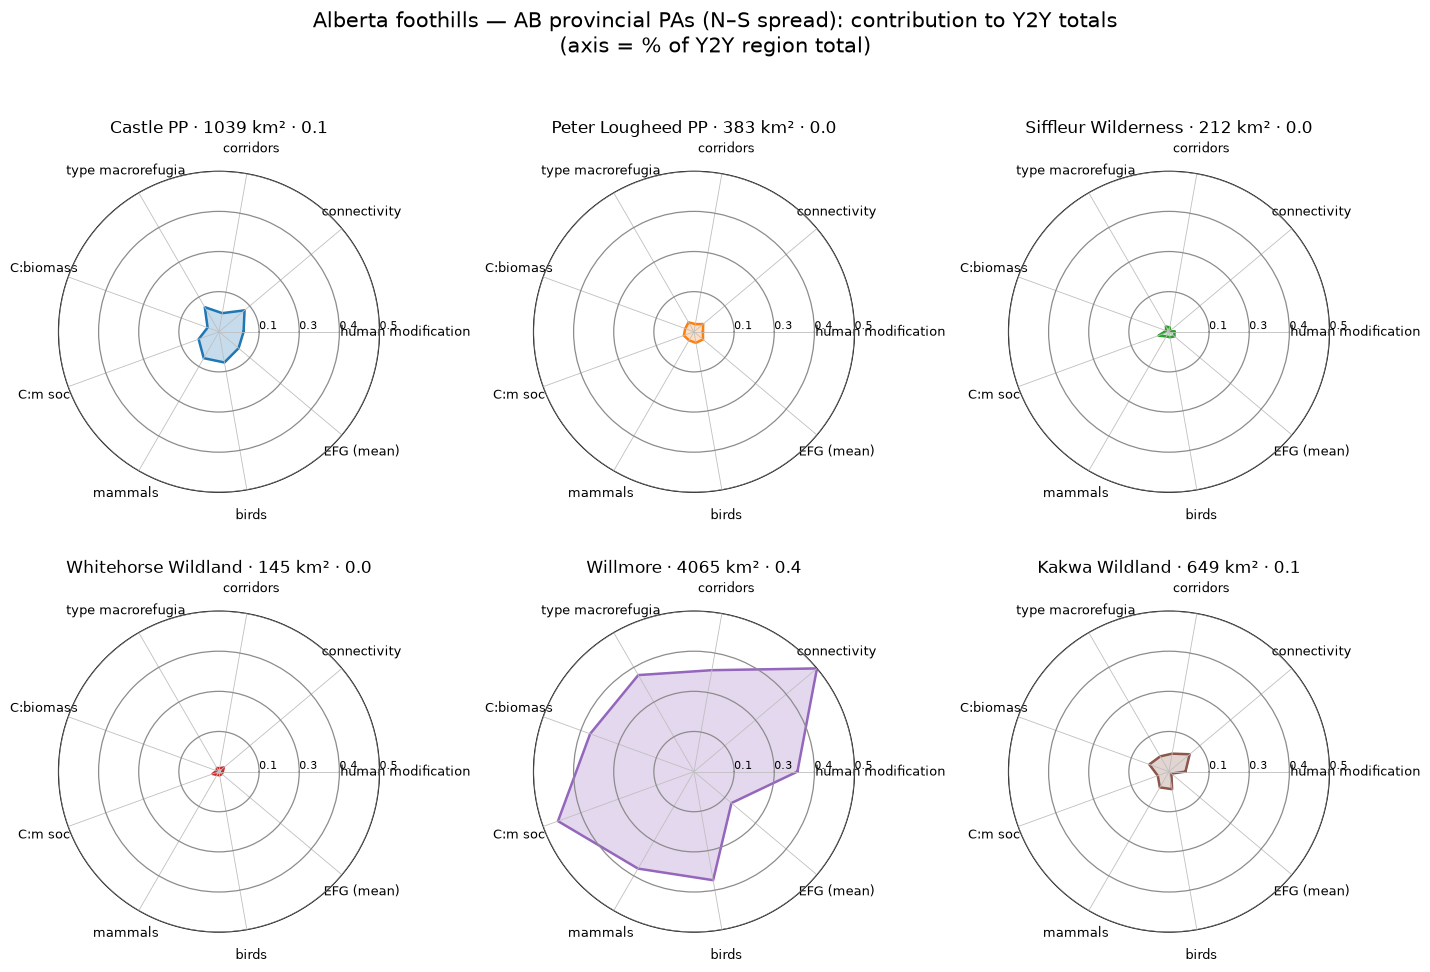

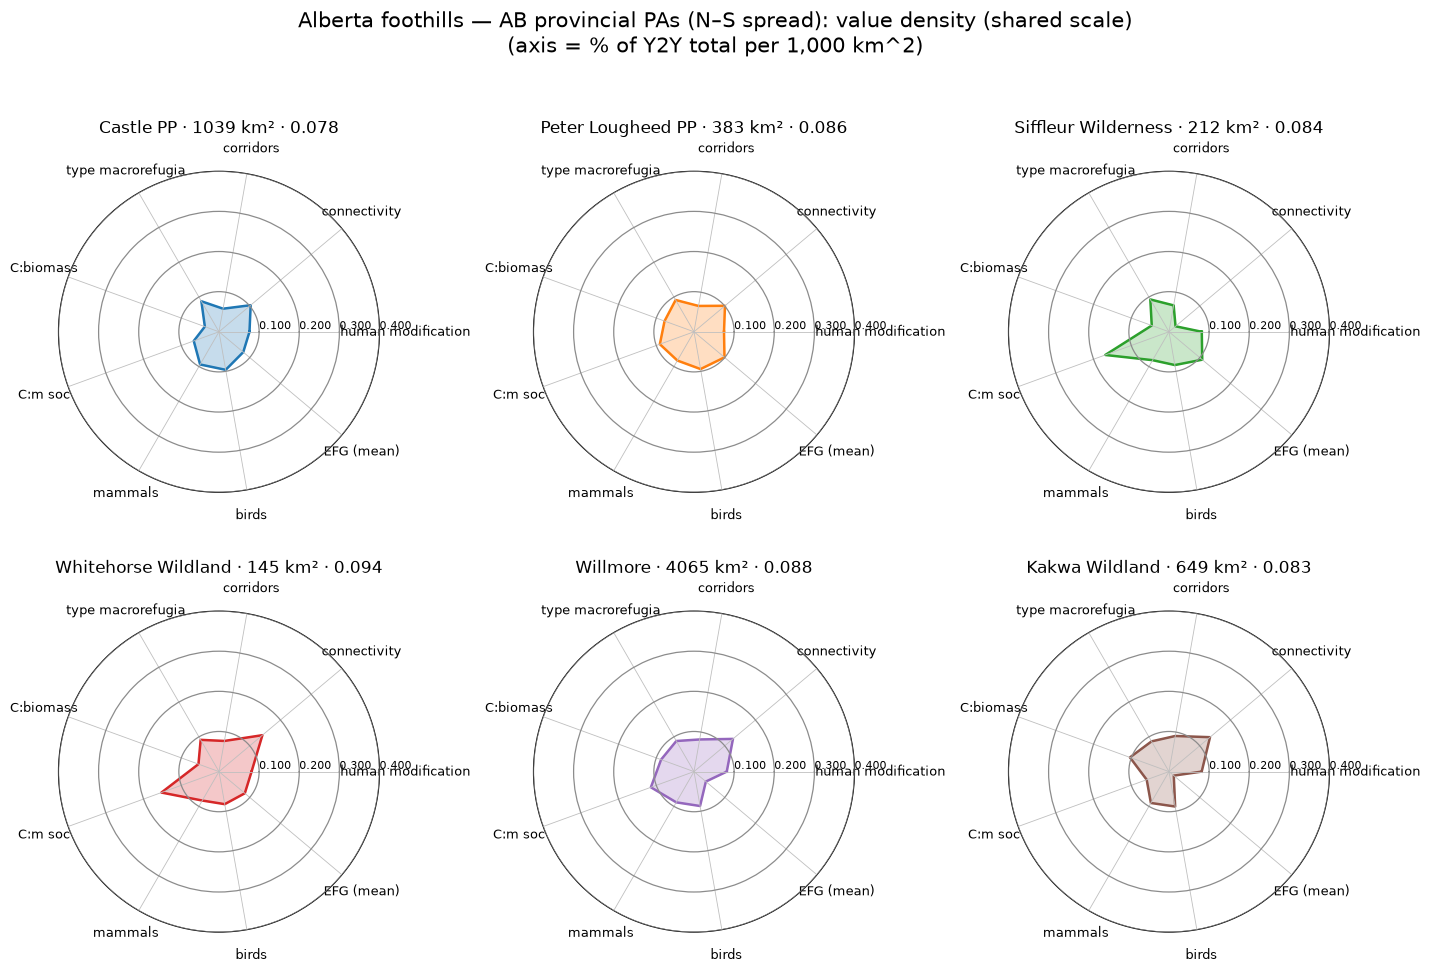

In [11]:
# ---- Benchmark areas: 3 star-plot views ----
rc.bench_stars(A)

In [12]:
# ---- Manual area (Ross River for y2y; no-op for the sub-regions) ----
rc.manual_block(A)

no manual area for this analysis


In [13]:
# ---- Consequences: transposed decision matrices (contribution / efficiency / raw) ----
rc.consequences(A)

CONTRIBUTION (% of Y2Y total):
  Contribution = area's share of the Y2Y region-wide total per input (%). Rows: 2 area metrics + 9 inputs; columns: areas.
                       Alternatives (new options)                                              Established Protected/Priority Areas                                                                                  
                                         Option 1 Option 2 Option 3 Option 4 Option 5 Option 6                            Castle PP Peter Lougheed PP Siffleur Wilderness Whitehorse Wildland Willmore Kakwa Wildland
area (km^2)                                 1,313      935      851      655      559      548                                1,039               383                 212                 145    4,065            649
area (% of Y2Y)                              0.10    0.073    0.067    0.051    0.044    0.043                                0.082             0.030               0.017               0.011     0.32      

(                                                   Alternatives (new options)                                                Established Protected/Priority Areas                                                                                  
                                                                      Option 1 Option 2 Option 3 Option 4   Option 5 Option 6                            Castle PP Peter Lougheed PP Siffleur Wilderness Whitehorse Wildland Willmore Kakwa Wildland
 Contribution = area's share of the Y2Y region-w...                                                                                                                                                                                                 
 area (km^2)                                                          1313.000  935.000  851.000  655.000  559.00000  548.000                             1039.000           383.000            212.0000            145.0000  4065.00        649.000
 area (% of Y2Y)    

In [14]:
# ---- Plain-language strongest / weakest summary per area ----
rc.plain_language(A)

Alberta foothills — per-area strongest / weakest inputs (by relative richness):

  [Alternatives (new options)]
  Option 1               strongest: Intactness, Climate refugia, Connectivity   |   weakest: Ecosystem groups (EFG), Carbon: mineral soil, Mammal richness
  Option 2               strongest: Bird richness, Intactness, Climate refugia   |   weakest: Ecosystem groups (EFG), Connectivity, Carbon: mineral soil
  Option 3               strongest: Bird richness, Intactness, Carbon: biomass   |   weakest: Ecosystem groups (EFG), Climate corridors, Connectivity
  Option 4               strongest: Climate corridors, Carbon: biomass, Intactness   |   weakest: Carbon: mineral soil, Ecosystem groups (EFG), Climate refugia
  Option 5               strongest: Climate corridors, Climate refugia, Intactness   |   weakest: Carbon: mineral soil, Carbon: biomass, Ecosystem groups (EFG)
  Option 6               strongest: Intactness, Climate refugia, Connectivity   |   weakest: Ecosystem groups 

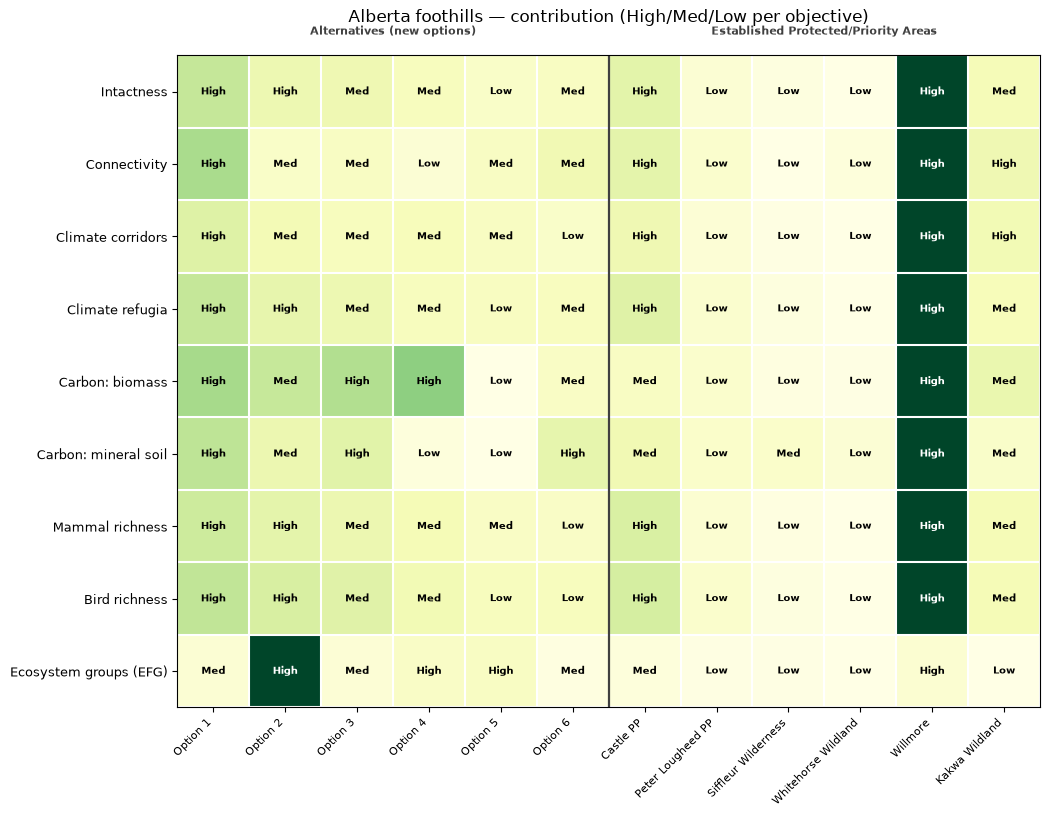

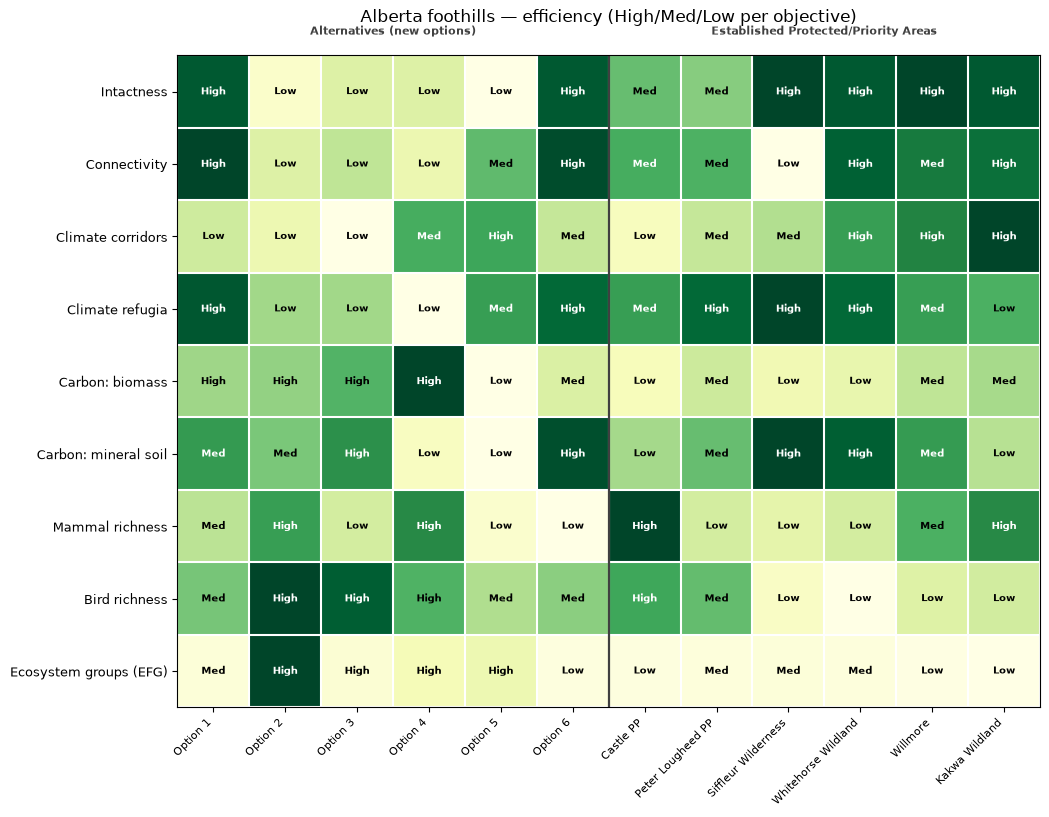

In [15]:
# ---- Colors-only High/Med/Low heatmaps (workshop / accessibility) ----
rc.heatmaps(A)